<a href="https://colab.research.google.com/github/GabrielSorge/Analise-estatistica-brasileirao-era-pontos-corridos/blob/main/analise_brasileirao_era_pontos_corridos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise Estatística — Brasileirão 2003–2025

Análise de desempenho dos times da Série A com base em 9.166 partidas.

**Perguntas respondidas:**
- Quais times têm melhor aproveitamento jogando como visitante? (mín. 100 jogos)
- Quais times têm melhor aproveitamento jogando como mandante? (mín. 100 jogos)
- Qual a distribuição de vitórias, empates e derrotas por time?
- Como se saíram os times que jogaram todas as edições?

**Dataset:** [Kaggle — Brazilian Football Matches 2003–2019](https://www.kaggle.com/datasets/rczekster/matches-brazilian-football-from-2003-to-2019)  
**Stack:** Python · Pandas · Matplotlib · Seaborn

## 1. Setup e Carregamento

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='Blues_r')

MIN_JOGOS = 100

df = pd.read_csv('matches-2003-2025.txt', sep=';', encoding='latin1')
df['#DATE'] = pd.to_datetime(df['#DATE'], dayfirst=True)

print(f'Partidas carregadas: {len(df):,}')
print(f'Período: {df["#DATE"].min().year} – {df["#DATE"].max().year}')
print(f'Times únicos: {df["HOME-TEAM"].nunique()}')
df.head()

Partidas carregadas: 9,166
Período: 2003 – 2025
Times únicos: 46


,#DATE,HOUR,HOME-TEAM,SCORE,AWAY-TEAM
0,2003-03-29,18:00,Guarani/SP,4x2,Vasco/RJ
1,2003-03-29,18:00,Atlético/PR,2x0,Grêmio/RS
2,2003-03-30,18:00,Goiás/GO,2x2,Paysandu/PA
3,2003-03-30,18:00,Corinthians/SP,0x3,Atlético/MG
4,2003-03-30,16:00,Flamengo/RJ,1x1,Coritiba/PR


## 2. Engenharia de Features

Extraímos o placar e calculamos resultado e pontos para mandante e visitante em uma única passagem sobre o DataFrame.

In [4]:
def parse_score(score: str) -> tuple[int, int]:
    """Recebe '2x1' e retorna (2, 1). Lança ValueError se o formato for inválido."""
    try:
        home, away = score.strip().split('x')
        return int(home), int(away)
    except Exception:
        raise ValueError(f"Formato de placar inesperado: '{score}'")


def resultado_e_pontos(score: str) -> pd.Series:
    """
    A partir do placar, retorna resultado e pontos para mandante e visitante.
    Retorna uma Series com 4 valores para uso com df.apply(axis=1).
    """
    home_gols, away_gols = parse_score(score)

    if home_gols > away_gols:
        res_home, res_away = 'vitoria', 'derrota'
        pts_home, pts_away = 3, 0
    elif home_gols == away_gols:
        res_home, res_away = 'empate', 'empate'
        pts_home, pts_away = 1, 1
    else:
        res_home, res_away = 'derrota', 'vitoria'
        pts_home, pts_away = 0, 3

    return pd.Series({
        'RES_MANDANTE':  res_home,
        'RES_VISITANTE': res_away,
        'PTS_MANDANTE':  pts_home,
        'PTS_VISITANTE': pts_away,
    })


df[['RES_MANDANTE', 'RES_VISITANTE', 'PTS_MANDANTE', 'PTS_VISITANTE']] = \
    df['SCORE'].apply(resultado_e_pontos)

print('Colunas criadas:', ['RES_MANDANTE', 'RES_VISITANTE', 'PTS_MANDANTE', 'PTS_VISITANTE'])
df[['HOME-TEAM', 'SCORE', 'AWAY-TEAM', 'RES_MANDANTE', 'RES_VISITANTE', 'PTS_MANDANTE', 'PTS_VISITANTE']].head()

Colunas criadas: ['RES_MANDANTE', 'RES_VISITANTE', 'PTS_MANDANTE', 'PTS_VISITANTE']


,HOME-TEAM,SCORE,AWAY-TEAM,RES_MANDANTE,RES_VISITANTE,PTS_MANDANTE,PTS_VISITANTE
0,Guarani/SP,4x2,Vasco/RJ,vitoria,derrota,3,0
1,Atlético/PR,2x0,Grêmio/RS,vitoria,derrota,3,0
2,Goiás/GO,2x2,Paysandu/PA,empate,empate,1,1
3,Corinthians/SP,0x3,Atlético/MG,derrota,vitoria,0,3
4,Flamengo/RJ,1x1,Coritiba/PR,empate,empate,1,1


## 3. Função Utilitária — Aproveitamento

Centraliza o cálculo de aproveitamento para evitar repetição de lógica nas análises seguintes.

In [5]:
def calcular_aproveitamento(
    df: pd.DataFrame,
    col_time: str,
    col_pontos: str,
    min_jogos: int = MIN_JOGOS
) -> pd.DataFrame:
    """
    Calcula aproveitamento (%) por time.

    Args:
        df:         DataFrame com os dados de partidas
        col_time:   coluna com o nome do time (ex: 'AWAY-TEAM')
        col_pontos: coluna com os pontos conquistados (ex: 'PTS_VISITANTE')
        min_jogos:  mínimo de jogos para não ser considerado outlier

    Returns:
        DataFrame com colunas: jogos, pontos, pontos_possiveis, aproveitamento_pct
    """
    resumo = df.groupby(col_time).agg(
        jogos=(col_time, 'count'),
        pontos=(col_pontos, 'sum')
    )

    resumo = resumo[resumo['jogos'] >= min_jogos].copy()
    resumo['pontos_possiveis'] = resumo['jogos'] * 3
    resumo['aproveitamento_pct'] = (resumo['pontos'] / resumo['pontos_possiveis'] * 100).round(2)

    return resumo.sort_values('aproveitamento_pct', ascending=False)


print('Função pronta.')

Função pronta.


## 4. Aproveitamento como Visitante

Melhor aproveitamento fora de casa — eliminando times com menos de 100 jogos como visitante.

In [6]:
aproveitamento_visitante = calcular_aproveitamento(df, 'AWAY-TEAM', 'PTS_VISITANTE')

print(f'Times analisados: {len(aproveitamento_visitante)}')
print('\nTop 10 — Melhor aproveitamento como visitante:')
print(aproveitamento_visitante[['jogos', 'pontos', 'aproveitamento_pct']].head(10).to_string())

Times analisados: 30

Top 10 — Melhor aproveitamento como visitante:
                  jogos  pontos  aproveitamento_pct
AWAY-TEAM                                          
Palmeiras/SP        405     532               43.79
Flamengo/RJ         447     570               42.51
São Paulo/SP        447     548               40.87
Cruzeiro/MG         390     470               40.17
Corinthians/SP      428     500               38.94
Internacional/RS    428     480               37.38
Atlético/MG         428     476               37.07
Fluminense/RJ       447     488               36.39
Botafogo/RJ         386     416               35.92
Santos/SP           428     458               35.67


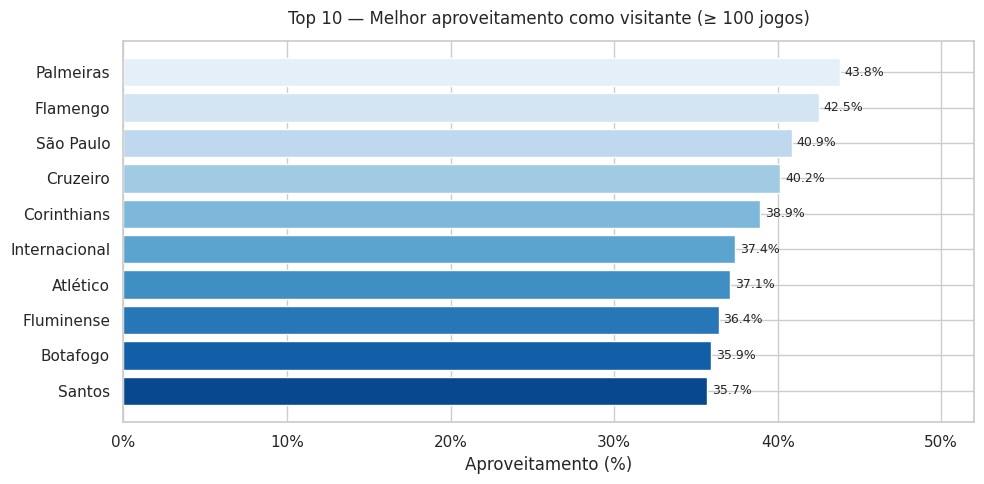

In [7]:
top10_visitante = aproveitamento_visitante.head(10).reset_index()
top10_visitante['time'] = top10_visitante['AWAY-TEAM'].str.replace(r'/\w+$', '', regex=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top10_visitante['time'][::-1], top10_visitante['aproveitamento_pct'][::-1],
               color=sns.color_palette('Blues_r', 10))

for bar, pct in zip(bars, top10_visitante['aproveitamento_pct'][::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%', va='center', fontsize=9)

ax.set_xlabel('Aproveitamento (%)')
ax.set_title('Top 10 — Melhor aproveitamento como visitante (≥ 100 jogos)', fontsize=12, pad=12)
ax.set_xlim(0, 52)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.tight_layout()
plt.savefig('visitante_aproveitamento.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Aproveitamento como Mandante

Melhor aproveitamento em casa — eliminando times com menos de 100 jogos como mandante.

In [8]:
aproveitamento_mandante = calcular_aproveitamento(df, 'HOME-TEAM', 'PTS_MANDANTE')

print(f'Times analisados: {len(aproveitamento_mandante)}')
print('\nTop 10 — Melhor aproveitamento como mandante:')
print(aproveitamento_mandante[['jogos', 'pontos', 'aproveitamento_pct']].head(10).to_string())

Times analisados: 30

Top 10 — Melhor aproveitamento como mandante:
                  jogos  pontos  aproveitamento_pct
HOME-TEAM                                          
São Paulo/SP        447     886               66.07
Internacional/RS    428     848               66.04
Grêmio/RS           407     800               65.52
Palmeiras/SP        405     794               65.35
Atlético/PR         409     790               64.38
Santos/SP           428     826               64.33
Flamengo/RJ         447     862               64.28
Corinthians/SP      428     810               63.08
Cruzeiro/MG         390     729               62.31
Atlético/MG         428     800               62.31


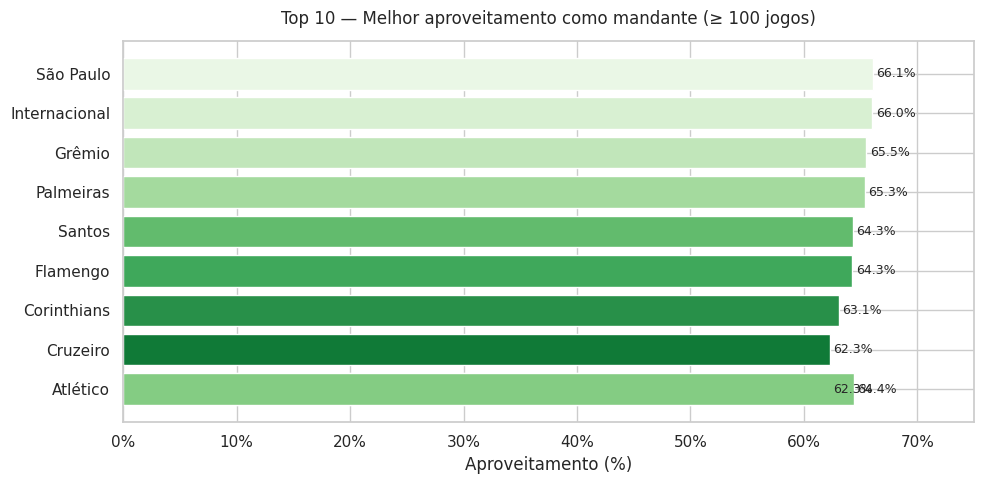

In [9]:
top10_mandante = aproveitamento_mandante.head(10).reset_index()
top10_mandante['time'] = top10_mandante['HOME-TEAM'].str.replace(r'/\w+$', '', regex=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top10_mandante['time'][::-1], top10_mandante['aproveitamento_pct'][::-1],
               color=sns.color_palette('Greens_r', 10))

for bar, pct in zip(bars, top10_mandante['aproveitamento_pct'][::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%', va='center', fontsize=9)

ax.set_xlabel('Aproveitamento (%)')
ax.set_title('Top 10 — Melhor aproveitamento como mandante (≥ 100 jogos)', fontsize=12, pad=12)
ax.set_xlim(0, 75)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.tight_layout()
plt.savefig('mandante_aproveitamento.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Distribuição de Resultados por Time

Vitórias, empates e derrotas consolidados (mandante + visitante) para os times com ≥ 100 jogos totais.

In [10]:
home_df = df[['HOME-TEAM', 'RES_MANDANTE']].rename(
    columns={'HOME-TEAM': 'time', 'RES_MANDANTE': 'resultado'})
away_df = df[['AWAY-TEAM', 'RES_VISITANTE']].rename(
    columns={'AWAY-TEAM': 'time', 'RES_VISITANTE': 'resultado'})

todos = pd.concat([home_df, away_df], ignore_index=True)

resultados = todos.groupby(['time', 'resultado']).size().unstack(fill_value=0)
resultados.columns.name = None
resultados['total'] = resultados.sum(axis=1)
resultados = resultados[resultados['total'] >= MIN_JOGOS * 2].drop(columns='total')

resultados = resultados.sort_values('vitoria', ascending=False)
resultados['time_limpo'] = resultados.index.str.replace(r'/\w+$', '', regex=True)

print('Distribuição de resultados (top 10 por vitórias):')
print(resultados.head(10).drop(columns='time_limpo').to_string())

Distribuição de resultados (top 10 por vitórias):
                  derrota  empate  vitoria
time                                      
Flamengo/RJ           256     241      397
São Paulo/SP          252     246      396
Palmeiras/SP          232     204      374
Internacional/RS      264     224      368
Corinthians/SP        252     251      353
Fluminense/RJ         311     230      353
Santos/SP             276     228      352
Atlético/MG           280     226      350
Grêmio/RS             269     204      341
Cruzeiro/MG           255     188      337


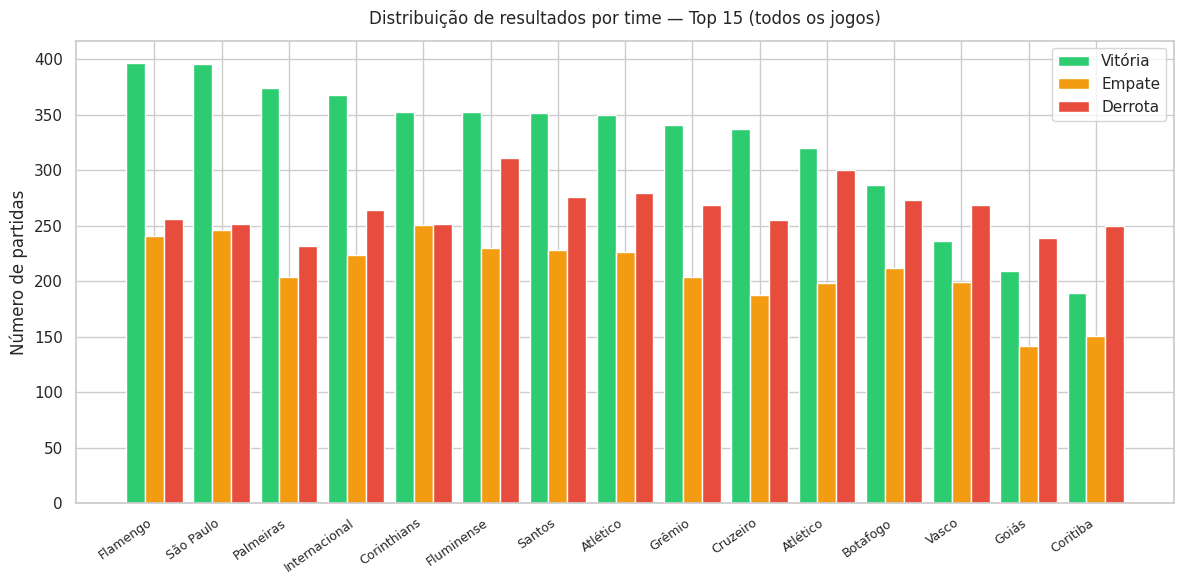

In [11]:
top15 = resultados.head(15)
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(top15))
width = 0.28

ax.bar([i - width for i in x], top15['vitoria'],  width, label='Vitória',  color='#2ecc71')
ax.bar([i         for i in x], top15['empate'],   width, label='Empate',   color='#f39c12')
ax.bar([i + width for i in x], top15['derrota'],  width, label='Derrota',  color='#e74c3c')

ax.set_xticks(list(x))
ax.set_xticklabels(top15['time_limpo'], rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Número de partidas')
ax.set_title('Distribuição de resultados por time — Top 15 (todos os jogos)', fontsize=12, pad=12)
ax.legend()
plt.tight_layout()
plt.savefig('distribuicao_resultados.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Times com Menos de 100 Jogos

Os times considerados outliers na análise principal — participação reduzida na Série A.

In [12]:
jogos_visitante = df.groupby('AWAY-TEAM').size().rename('jogos')
outliers = jogos_visitante[jogos_visitante < MIN_JOGOS].sort_values()

print(f'Times com menos de {MIN_JOGOS} jogos como visitante: {len(outliers)}')
print(outliers.to_string())

Times com menos de 100 jogos como visitante: 16
AWAY-TEAM
América/RN            19
Barueri/SP            19
CSA/AL                19
Grêmio Prudente/SP    19
Ipatinga/MG           19
Santo André/SP        19
Mirassol/SP           19
Joinville/SC          19
Brasiliense/DF        21
Santa Cruz/PE         38
Portuguesa/SP         57
Guarani/SP            65
Paysandu/PA           67
Cuiabá/MT             76
São Caetano/SP        86
Náutico/PE            95


## 8. Times que Disputaram Todas as Edições

Identifiquei os times presentes em todas as edições do Brasileirão no dataset e comparei seu aproveitamento geral.

In [13]:
df['ano'] = df['#DATE'].dt.year
total_edicoes = df['ano'].nunique()

edicoes_por_time = df.groupby('HOME-TEAM')['ano'].nunique()
times_todas_edicoes = edicoes_por_time[edicoes_por_time == total_edicoes].index.tolist()

print(f'Total de edições no dataset: {total_edicoes}')
print(f'Times presentes em todas as edições ({len(times_todas_edicoes)}): {sorted(times_todas_edicoes)}')

Total de edições no dataset: 23
Times presentes em todas as edições (3): ['Flamengo/RJ', 'Fluminense/RJ', 'São Paulo/SP']


In [14]:
home_pts = df[df['HOME-TEAM'].isin(times_todas_edicoes)].groupby('HOME-TEAM').agg(
    jogos_casa=('HOME-TEAM', 'count'), pts_casa=('PTS_MANDANTE', 'sum'))

away_pts = df[df['AWAY-TEAM'].isin(times_todas_edicoes)].groupby('AWAY-TEAM').agg(
    jogos_fora=('AWAY-TEAM', 'count'), pts_fora=('PTS_VISITANTE', 'sum'))

geral = home_pts.join(away_pts, how='inner')
geral['total_jogos'] = geral['jogos_casa'] + geral['jogos_fora']
geral['total_pontos'] = geral['pts_casa'] + geral['pts_fora']
geral['aproveitamento_geral'] = (geral['total_pontos'] / (geral['total_jogos'] * 3) * 100).round(2)
geral = geral.sort_values('aproveitamento_geral', ascending=False)
geral['time'] = geral.index.str.replace(r'/\w+$', '', regex=True)

print('Aproveitamento geral — times em todas as edições:')
print(geral[['total_jogos', 'total_pontos', 'aproveitamento_geral']].to_string())

Aproveitamento geral — times em todas as edições:
               total_jogos  total_pontos  aproveitamento_geral
HOME-TEAM                                                     
São Paulo/SP           894          1434                 53.47
Flamengo/RJ            894          1432                 53.39
Fluminense/RJ          894          1289                 48.06


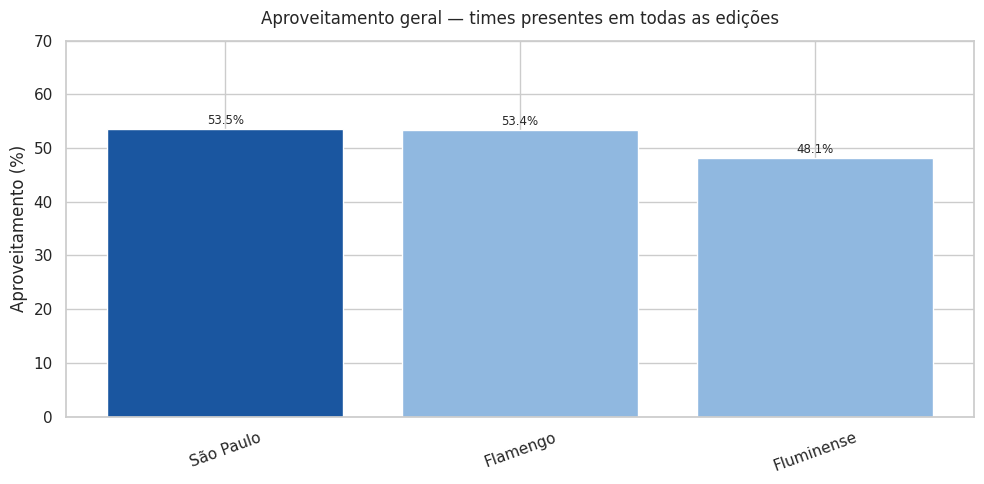

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#1a56a0' if v == geral['aproveitamento_geral'].max() else '#90b8e0'
          for v in geral['aproveitamento_geral']]

bars = ax.bar(geral['time'], geral['aproveitamento_geral'], color=colors)

for bar, pct in zip(bars, geral['aproveitamento_geral']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=8.5)

ax.set_ylabel('Aproveitamento (%)')
ax.set_ylim(0, 70)
ax.set_title('Aproveitamento geral — times presentes em todas as edições', fontsize=12, pad=12)
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('todas_edicoes_aproveitamento.png', dpi=150, bbox_inches='tight')
plt.show()